Upload your image


Saving sample.jpg to sample (1).jpg


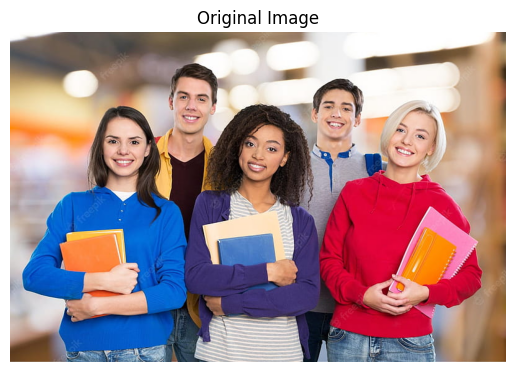

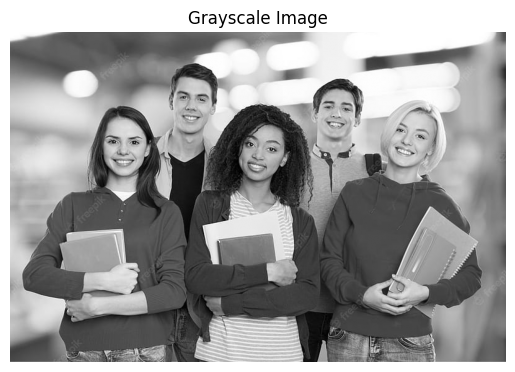

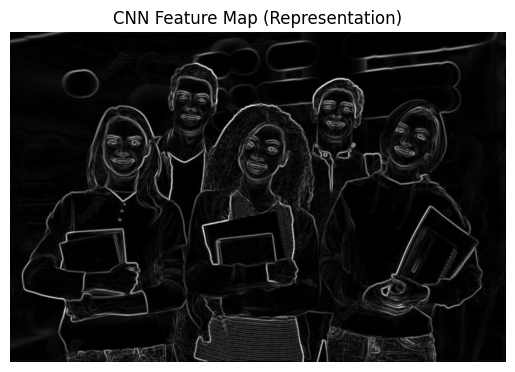

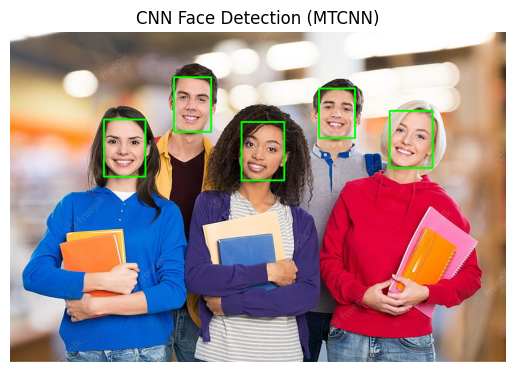

Number of faces detected: 5


In [5]:
!pip install mtcnn opencv-python matplotlib -q
import cv2
import numpy as np
import matplotlib.pyplot as plt
from mtcnn import MTCNN
from google.colab import files
print("Upload your image")
uploaded = files.upload()
filename = list(uploaded.keys())[0]
img = cv2.imread(filename)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img_rgb)
plt.title("Original Image")
plt.axis("off")
plt.show()
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale Image")
plt.axis("off")
plt.show()
sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=5)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=5)
feature_map = cv2.magnitude(sobelx, sobely)
feature_map = (feature_map - feature_map.min()) / (feature_map.max() - feature_map.min())
plt.imshow(feature_map, cmap='gray')
plt.title("CNN Feature Map (Representation)")
plt.axis("off")
plt.show()
detector = MTCNN()
faces = detector.detect_faces(img_rgb)
output = img_rgb.copy()
for face in faces:
  x, y, width, height = face['box']
  cv2.rectangle(output, (x, y), (x+width, y+height), (0,255,0), 2)
plt.imshow(output)
plt.title("CNN Face Detection (MTCNN)")
plt.axis("off")
plt.show()
print("Number of faces detected:", len(faces))